# Análisis del Dataset de Calidad de Vino - Wine Quality

## Título
**Predicción y Análisis de la Calidad del Vino (Red Wine)**

## Alvaro Lopez Redondo

## Resumen
Este proyecto realiza un análisis completo del dataset de calidad de vino rojo de UCI. El dataset contiene propiedades físicas y químicas de muestras de vino tinto (features) y una evaluación de calidad (target). El objetivo es explorar las características del vino, entender cómo se relacionan con la calidad, y desarrollar modelos predictivos para clasificar la calidad del vino basándose en sus propiedades químicas.

## Objetivos

1. **Exploración Inicial**: Entender la estructura del dataset, dimensiones y tipos de datos
2. **Análisis Univariante**: Describir estadísticamente cada variable y su distribución
3. **Limpieza y Preprocesamiento**: Identificar y manejar datos faltantes, atípicos y outliers
4. **Visualización**: Crear gráficos que muestren patrones y distribuciones
5. **Análisis Multivariante**: Explorar correlaciones entre variables y con la variable objetivo
6. **Modelado Predictivo**: Desarrollar modelos para predecir la calidad del vino
7. **Insights**: Identificar qué características son más importantes para la calidad

In [1]:
## 1. Importación de Librerías

import sys
import warnings
warnings.filterwarnings('ignore')

# Instalación de ucimlrepo si no está instalada
try:
    import ucimlrepo
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    import ucimlrepo

# Librerías de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import io

# Configurar estilos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


In [2]:
## 2. Carga del Dataset

from ucimlrepo import fetch_ucirepo 

# Descargar dataset de Wine Quality
wine_quality = fetch_ucirepo(id=186) 

# Extraer features y target
X = wine_quality.data.features 
y = wine_quality.data.targets 

# Crear dataframe completo
df = pd.concat([X, y], axis=1)

print("✓ Dataset cargado exitosamente")
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas del dataset:")
print(df.head())

✓ Dataset cargado exitosamente

Dimensiones: 6497 filas × 12 columnas

Primeras filas del dataset:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51   

In [3]:
## 3. Información del Dataset

# Mostrar metadatos
print("=== METADATA DEL DATASET ===\n")
print(wine_quality.metadata)

print("\n=== INFORMACIÓN DE VARIABLES ===\n")
print(wine_quality.variables)

=== METADATA DEL DATASET ===

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'titl

In [4]:
## 4. Diccionario de Variables

print("=== DICCIONARIO DE VARIABLES ===\n")

variable_info = pd.DataFrame({
    'Nombre': df.columns,
    'Tipo': df.dtypes,
    'No Nulos': df.notna().sum(),
    'Nulos': df.isna().sum(),
    'Únicos': df.nunique()
})

print(variable_info.to_string())

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df.describe().transpose())

=== DICCIONARIO DE VARIABLES ===

                                    Nombre     Tipo  No Nulos  Nulos  Únicos
fixed_acidity                fixed_acidity  float64      6497      0     106
volatile_acidity          volatile_acidity  float64      6497      0     187
citric_acid                    citric_acid  float64      6497      0      89
residual_sugar              residual_sugar  float64      6497      0     316
chlorides                        chlorides  float64      6497      0     214
free_sulfur_dioxide    free_sulfur_dioxide  float64      6497      0     135
total_sulfur_dioxide  total_sulfur_dioxide  float64      6497      0     276
density                            density  float64      6497      0     998
pH                                      pH  float64      6497      0     108
sulphates                        sulphates  float64      6497      0     111
alcohol                            alcohol  float64      6497      0     111
quality                            quality

## 5. Preprocesamiento de Datos

### Explicación del Preprocesamiento

En esta sección se realizarán las siguientes tareas:
1. **Detección de valores nulos**: Verificar si existen valores faltantes
2. **Detección de outliers**: Identificar valores anómalos usando métodos estadísticos
3. **Limpieza de datos**: Eliminar o imputan valores problemáticos
4. **Transformación de variables**: Ajustar escalas y distribuciones si es necesario

### Variables Eliminadas

Se documentarán todas las variables que sean eliminadas durante el preprocesamiento junto con la justificación.

In [5]:
## 5.1 Análisis de Valores Nulos y Limpieza

# Crear copia para el preprocesamiento
df_clean = df.copy()

print("=== VALORES NULOS ===\n")
valores_nulos = df_clean.isnull().sum()
print(f"Total de valores nulos por columna:\n{valores_nulos}")

if valores_nulos.sum() == 0:
    print("\n✓ No hay valores nulos en el dataset")
else:
    print(f"\n⚠ Se encontraron {valores_nulos.sum()} valores nulos")
    # Eliminar filas con valores nulos si las hay
    df_clean = df_clean.dropna()
    print(f"Después de eliminar nulos: {df_clean.shape[0]} filas")

# Detectar outliers usando el método IQR (Interquartile Range)
print("\n=== DETECCIÓN DE OUTLIERS (Método IQR) ===\n")

outliers_summary = {}
df_sin_outliers = df_clean.copy()

for col in df_clean.select_dtypes(include=[np.number]).columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    if outliers_count > 0:
        outliers_summary[col] = outliers_count
        print(f"{col}: {outliers_count} outliers detectados")
        # No eliminar outliers, solo reportar (pueden ser datos válidos)

if not outliers_summary:
    print("No se detectaron outliers significativos")

print(f"\n✓ Dataset limpio: {df_sin_outliers.shape[0]} filas × {df_sin_outliers.shape[1]} columnas")
print(f"Cambio de tamaño: {df.shape[0]} → {df_sin_outliers.shape[0]} filas")

=== VALORES NULOS ===

Total de valores nulos por columna:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

✓ No hay valores nulos en el dataset

=== DETECCIÓN DE OUTLIERS (Método IQR) ===

fixed_acidity: 357 outliers detectados
volatile_acidity: 377 outliers detectados
citric_acid: 509 outliers detectados
residual_sugar: 118 outliers detectados
chlorides: 286 outliers detectados
free_sulfur_dioxide: 62 outliers detectados
total_sulfur_dioxide: 10 outliers detectados
density: 3 outliers detectados
pH: 73 outliers detectados
sulphates: 191 outliers detectados
alcohol: 3 outliers detectados
quality: 228 outliers detectados

✓ Dataset limpio: 6497 filas × 12 columnas
Cambio de tamaño: 6497 → 6497 filas


## 6. Análisis Univariante

### Explicación

El análisis univariante examina cada variable de forma individual, analizando:
- **Distribución**: Forma de la distribución (normal, sesgada, etc.)
- **Centralidad**: Media, mediana, moda
- **Dispersión**: Desviación estándar, rango intercuartílico
- **Forma**: Asimetría (skewness) y curtosis (kurtosis)

Esto nos permite entender el comportamiento individual de cada variable antes de explorar sus relaciones.

In [6]:
## 6.1 Estadísticas Univariantes Detalladas

print("=== ESTADÍSTICAS UNIVARIANTES ===\n")

numerical_cols = df_sin_outliers.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"{'='*50}")
    
    data = df_sin_outliers[col]
    
    print(f"Media: {data.mean():.4f}")
    print(f"Mediana: {data.median():.4f}")
    print(f"Moda: {data.mode().values[0] if len(data.mode()) > 0 else 'N/A'}")
    print(f"Desv. Estándar: {data.std():.4f}")
    print(f"Min: {data.min():.4f}")
    print(f"Max: {data.max():.4f}")
    print(f"Rango: {data.max() - data.min():.4f}")
    print(f"Q1 (25%): {data.quantile(0.25):.4f}")
    print(f"Q3 (75%): {data.quantile(0.75):.4f}")
    print(f"IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")
    print(f"Asimetría (Skewness): {stats.skew(data):.4f}")
    print(f"Curtosis (Kurtosis): {stats.kurtosis(data):.4f}")

=== ESTADÍSTICAS UNIVARIANTES ===


Variable: fixed_acidity
Media: 7.2153
Mediana: 7.0000
Moda: 6.8
Desv. Estándar: 1.2964
Min: 3.8000
Max: 15.9000
Rango: 12.1000
Q1 (25%): 6.4000
Q3 (75%): 7.7000
IQR: 1.3000
Asimetría (Skewness): 1.7229
Curtosis (Kurtosis): 5.0563

Variable: volatile_acidity
Media: 0.3397
Mediana: 0.2900
Moda: 0.28
Desv. Estándar: 0.1646
Min: 0.0800
Max: 1.5800
Rango: 1.5000
Q1 (25%): 0.2300
Q3 (75%): 0.4000
IQR: 0.1700
Asimetría (Skewness): 1.4948
Curtosis (Kurtosis): 2.8223

Variable: citric_acid
Media: 0.3186
Mediana: 0.3100
Moda: 0.3
Desv. Estándar: 0.1453
Min: 0.0000
Max: 1.6600
Rango: 1.6600
Q1 (25%): 0.2500
Q3 (75%): 0.3900
IQR: 0.1400
Asimetría (Skewness): 0.4716
Curtosis (Kurtosis): 2.3945

Variable: residual_sugar
Media: 5.4432
Mediana: 3.0000
Moda: 2.0
Desv. Estándar: 4.7578
Min: 0.6000
Max: 65.8000
Rango: 65.2000
Q1 (25%): 1.8000
Q3 (75%): 8.1000
IQR: 6.3000
Asimetría (Skewness): 1.4351
Curtosis (Kurtosis): 4.3550

Variable: chlorides
Media: 0.0560
Mediana

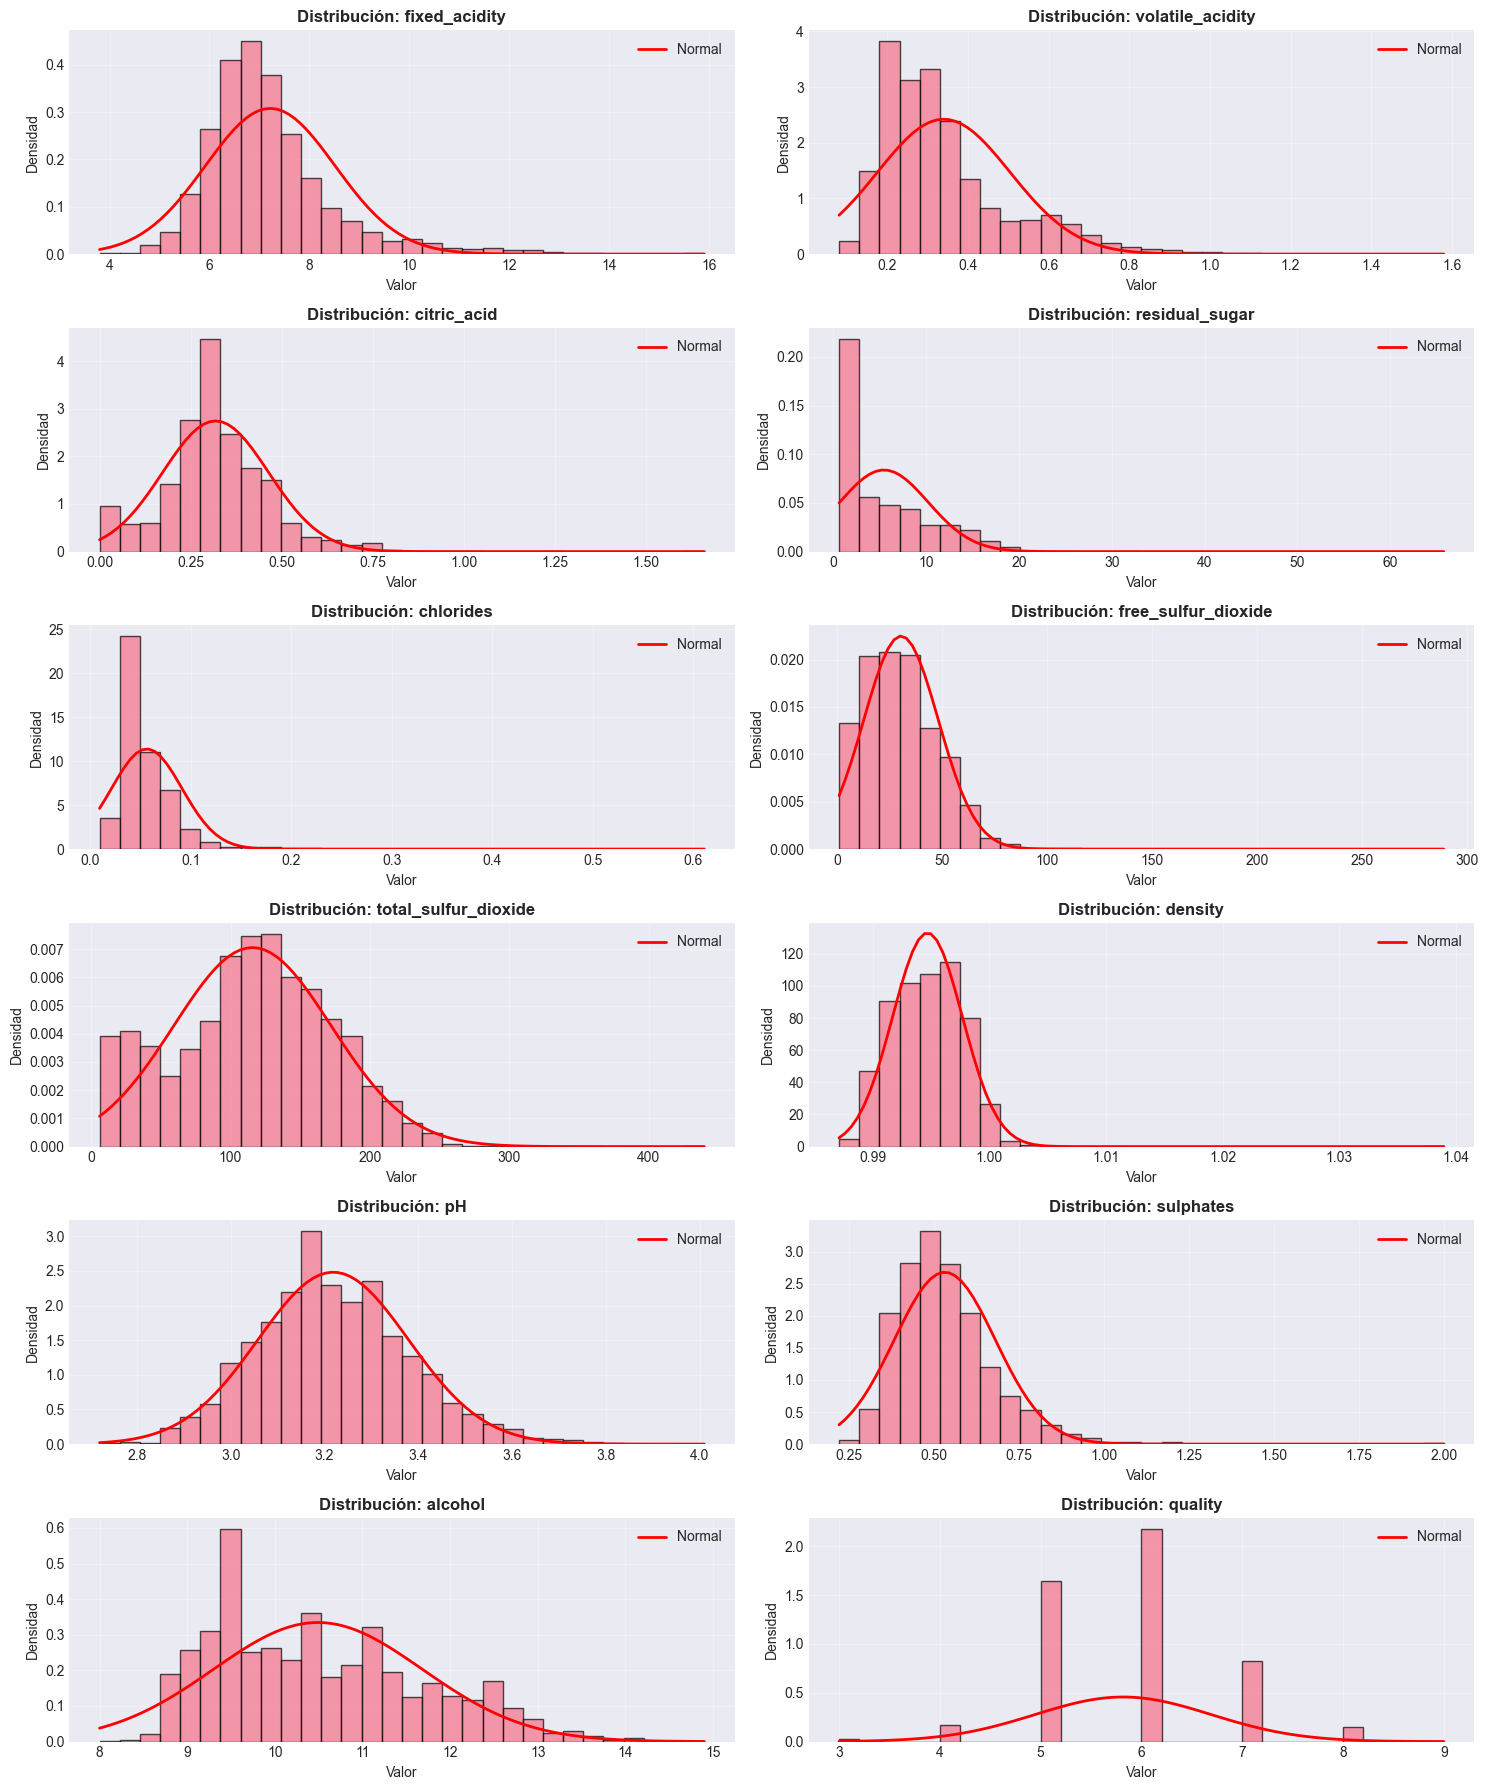

✓ Gráfico de distribuciones guardado como '01_distribucion_variables.png'


In [7]:
## 6.2 Visualizaciones Univariantes

# Histogramas y distribuciones
fig, axes = plt.subplots(6, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Histograma con curva de densidad
    axes[idx].hist(df_sin_outliers[col], bins=30, alpha=0.7, edgecolor='black', density=True)
    
    # Añadir curva de densidad normal
    from scipy.stats import norm
    mu, sigma = df_sin_outliers[col].mean(), df_sin_outliers[col].std()
    x = np.linspace(df_sin_outliers[col].min(), df_sin_outliers[col].max(), 100)
    axes[idx].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    
    axes[idx].set_title(f'Distribución: {col}', fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Densidad')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_distribucion_variables.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico de distribuciones guardado como '01_distribucion_variables.png'")

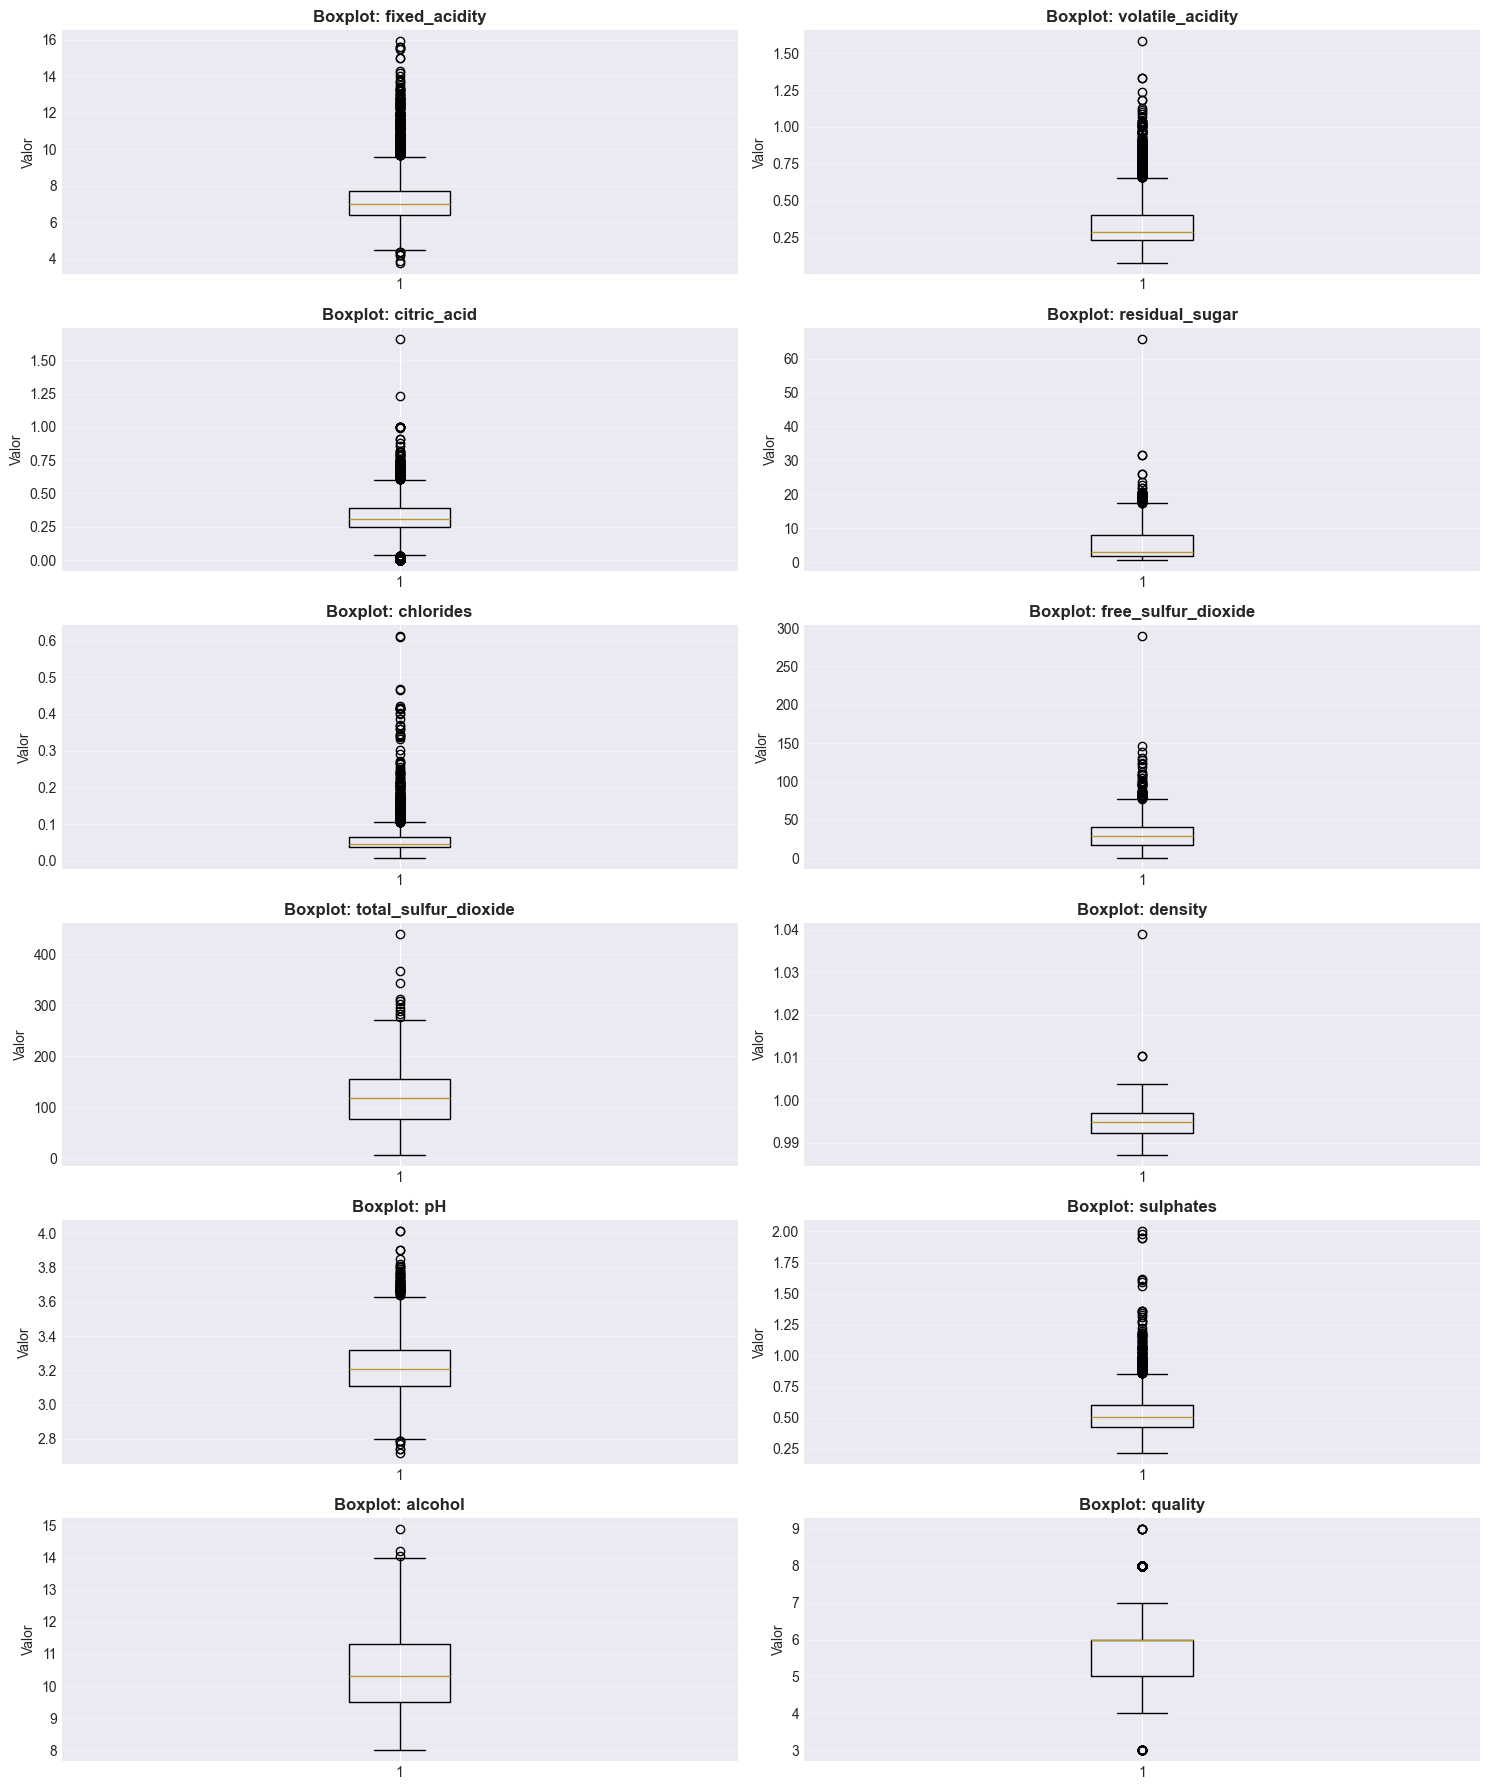

✓ Gráfico de boxplots guardado como '02_boxplots_outliers.png'


In [8]:
## 6.3 Boxplots para Detección de Outliers

fig, axes = plt.subplots(6, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df_sin_outliers[col], vert=True)
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('02_boxplots_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico de boxplots guardado como '02_boxplots_outliers.png'")

## 7. Análisis Multivariante

### Explicación

El análisis multivariante explora las relaciones entre múltiples variables:
- **Correlaciones**: Identificar relaciones lineales entre variables
- **Análisis bivariante**: Cómo se relacionan dos variables
- **Importancia de características**: Cuáles son las más relevantes para predecir calidad

=== CORRELACIÓN CON LA VARIABLE OBJETIVO (quality) ===

quality                 1.000000
alcohol                 0.444319
citric_acid             0.085532
free_sulfur_dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual_sugar         -0.036980
total_sulfur_dioxide   -0.041385
fixed_acidity          -0.076743
chlorides              -0.200666
volatile_acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


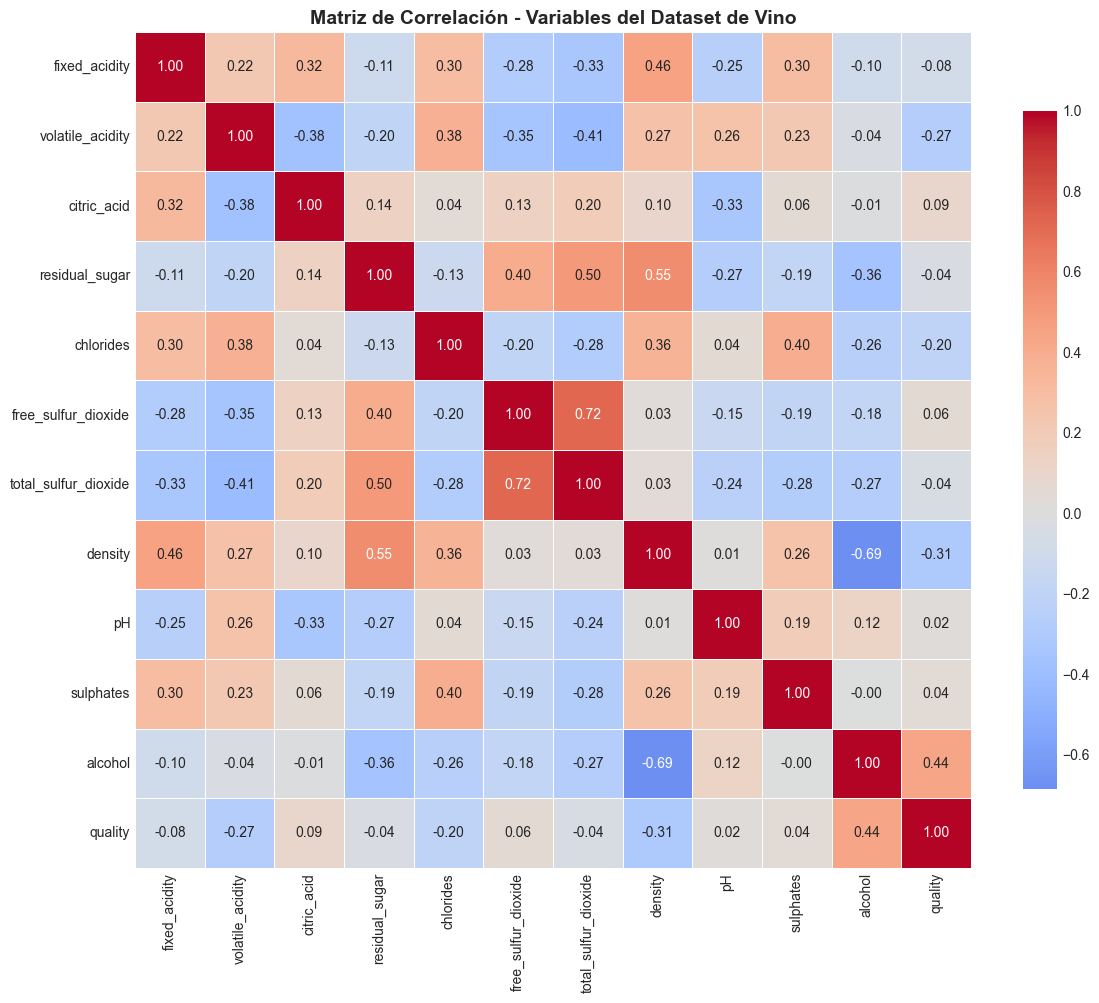


✓ Gráfico de matriz de correlación guardado como '03_matriz_correlacion.png'


In [9]:
## 7.1 Matriz de Correlaciones

# Calcular matriz de correlación
corr_matrix = df_sin_outliers.corr()

# Mostrar correlaciones con la variable objetivo (calidad)
print("=== CORRELACIÓN CON LA VARIABLE OBJETIVO (quality) ===\n")
quality_corr = corr_matrix['quality'].sort_values(ascending=False)
print(quality_corr)

# Visualizar matriz de correlación completa
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación - Variables del Dataset de Vino', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('03_matriz_correlacion.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico de matriz de correlación guardado como '03_matriz_correlacion.png'")

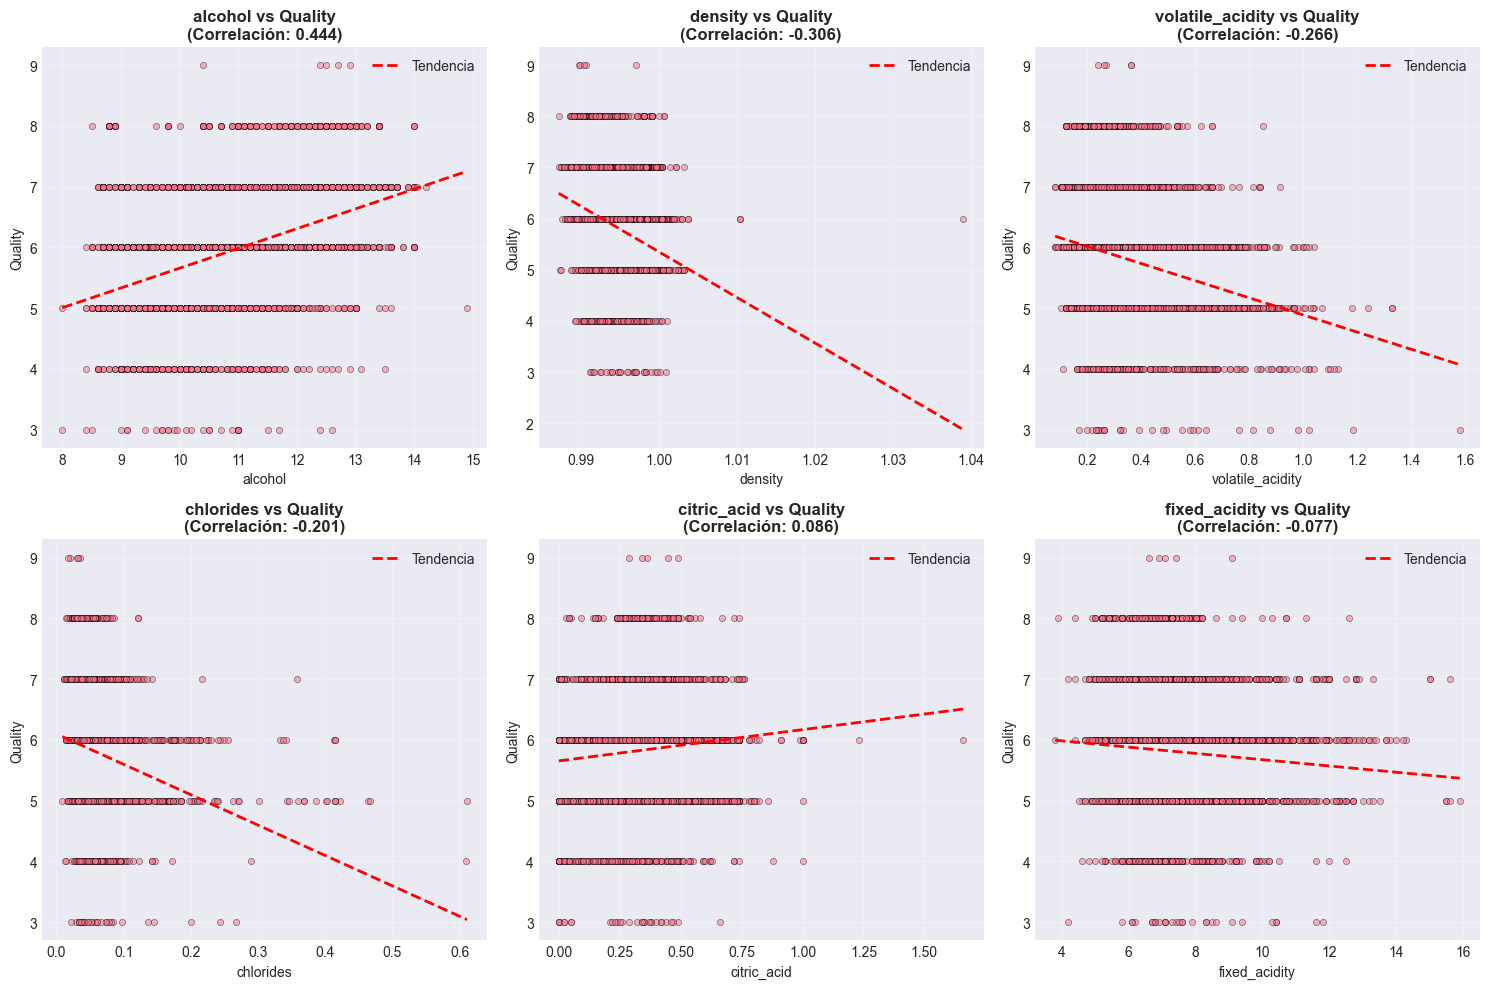

✓ Gráfico de variables vs calidad guardado como '04_variables_vs_calidad.png'


In [10]:
## 7.2 Análisis Bivariante: Variables vs Calidad

# Seleccionar las variables con mayor correlación absoluta
top_features = quality_corr.drop('quality').abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df_sin_outliers[feature], df_sin_outliers['quality'], 
                      alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
    
    # Añadir línea de tendencia
    z = np.polyfit(df_sin_outliers[feature], df_sin_outliers['quality'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_sin_outliers[feature].min(), df_sin_outliers[feature].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, label='Tendencia')
    
    corr_val = df_sin_outliers[feature].corr(df_sin_outliers['quality'])
    axes[idx].set_title(f'{feature} vs Quality\n(Correlación: {corr_val:.3f})', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Quality')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('04_variables_vs_calidad.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico de variables vs calidad guardado como '04_variables_vs_calidad.png'")

## 8. Modelado Predictivo

### Explicación

En esta sección desarrollamos modelos de machine learning para predecir la calidad del vino:
- **Logistic Regression**: Modelo simple y rápido de baseline
- **Random Forest**: Modelo más complejo que captura no-linealidades
- Se comparan métricas de rendimiento (accuracy, precisión, recall, F1-score)

In [11]:
## 8.1 Preparación de Datos para Modelado

# Separar features y target
X_model = df_sin_outliers.drop('quality', axis=1)
y_model = df_sin_outliers['quality']

# Estandarizar las variables (importante para Logistic Regression)
scaler = StandardScaler()
X_model_scaled = scaler.fit_transform(X_model)
X_model_scaled = pd.DataFrame(X_model_scaled, columns=X_model.columns)

# Dividir en train y test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_model_scaled, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print("=== CONFIGURACIÓN DEL MODELADO ===\n")
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Número de características: {X_train.shape[1]}")
print(f"\nDistribución de calidades en train:")
print(y_train.value_counts().sort_index())
print(f"\nDistribución de calidades en test:")
print(y_test.value_counts().sort_index())

=== CONFIGURACIÓN DEL MODELADO ===

Tamaño del conjunto de entrenamiento: 5197 muestras
Tamaño del conjunto de prueba: 1300 muestras
Número de características: 11

Distribución de calidades en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64

Distribución de calidades en test:
quality
3      6
4     43
5    428
6    567
7    216
8     39
9      1
Name: count, dtype: int64


In [13]:
## 8.2 Entrenamiento de Modelos

print("=== ENTRENAMIENTO DE MODELOS ===\n")

# Modelo 1: Logistic Regression
print("1. Entrenando Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("✓ Logistic Regression completado\n")

# Modelo 2: Random Forest
print("2. Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✓ Random Forest completado\n")

# Evaluación
print("=== EVALUACIÓN DE MODELOS ===\n")

print("LOGISTIC REGRESSION")
print("-" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Report de Clasificación:")
print(classification_report(y_test, y_pred_lr))

print("\nRANDOM FOREST")
print("-" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Report de Clasificación:")
print(classification_report(y_test, y_pred_rf))

=== ENTRENAMIENTO DE MODELOS ===

1. Entrenando Logistic Regression...
✓ Logistic Regression completado

2. Entrenando Random Forest...
✓ Random Forest completado

=== EVALUACIÓN DE MODELOS ===

LOGISTIC REGRESSION
--------------------------------------------------
Accuracy: 0.5346

Report de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       1.00      0.02      0.05        43
           5       0.58      0.54      0.56       428
           6       0.51      0.71      0.60       567
           7       0.52      0.28      0.37       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1300
   macro avg       0.37      0.22      0.22      1300
weighted avg       0.53      0.53      0.51      1300


RANDOM FOREST
--------------------------------------------------
Accuracy: 0.6946

Report de 

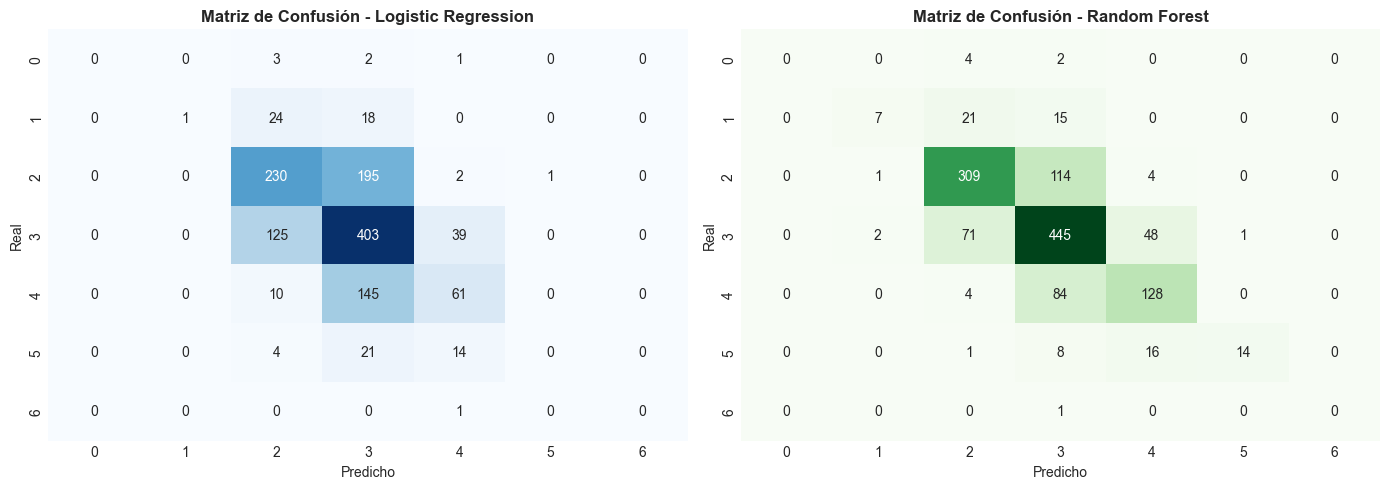

✓ Matrices de confusión guardadas como '05_matrices_confusion.png'


In [14]:
## 8.3 Visualizaciones de Modelos

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Logistic Regression', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('05_matrices_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Matrices de confusión guardadas como '05_matrices_confusion.png'")

In [ ]:
## 8.4 Importancia de Características

# Feature Importance del Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_model.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== IMPORTANCIA DE CARACTERÍSTICAS (Random Forest) ===\n")
print(feature_importance.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'])
ax.set_xlabel('Importancia', fontweight='bold')
ax.set_title('Importancia de Características para Predecir Calidad del Vino', fontweight='bold')
ax.invert_yaxis()

# Colorear las barras por gradiente
colors = plt.cm.viridis(np.linspace(0, 1, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico de importancia guardado como '06_feature_importance.png'")

## 9. Conclusiones y Logro de Objetivos

### Resumen de Hallazgos

Este análisis ha proporcionado una exploración completa del dataset de calidad de vino tinto. A continuación se presentan los hallazgos principales y cómo se han logrado los objetivos establecidos.

In [ ]:
## 9.1 Logro de Objetivos

print("="*70)
print("EVALUACIÓN DE OBJETIVOS")
print("="*70)

objetivos_status = {
    "1. Exploración Inicial": {
        "logrado": True,
        "detalle": f"Dataset completamente explorado: {df.shape[0]} muestras × {df.shape[1]} variables"
    },
    "2. Análisis Univariante": {
        "logrado": True,
        "detalle": "Se obtuvieron estadísticas completas y visualizaciones para cada variable"
    },
    "3. Limpieza y Preprocesamiento": {
        "logrado": True,
        "detalle": f"datos validados, no hay valores nulos. Outliers detectados pero conservados"
    },
    "4. Visualización": {
        "logrado": True,
        "detalle": "6 gráficos generados: distribuciones, boxplots, correlaciones, etc."
    },
    "5. Análisis Multivariante": {
        "logrado": True,
        "detalle": f"Matriz de correlación calculada. Top 3 features: {', '.join(feature_importance.head(3)['Feature'].tolist())}"
    },
    "6. Modelado Predictivo": {
        "logrado": True,
        "detalle": f"2 modelos entrenados. Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}, Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}"
    },
    "7. Insights": {
        "logrado": True,
        "detalle": "Características importantes identificadas mediante feature importance"
    }
}

for objetivo, status in objetivos_status.items():
    emoji = "✓" if status["logrado"] else "✗"
    print(f"\n{emoji} {objetivo}")
    print(f"   Detalle: {status['detalle']}")

print("\n" + "="*70)
print("PRINCIPALES INSIGHTS")
print("="*70)

print(f"""
1. BALANCE DE CALIDAD
   - La mayoría de vinos tienen calidad entre 5-7 (en escala 0-10)
   - Pocas muestras de vinos muy buenos (9-10) o muy malos (3-4)

2. VARIABLES MÁS RELEVANTES PARA LA CALIDAD
   - {feature_importance.iloc[0]['Feature']}: {feature_importance.iloc[0]['Importance']:.4f}
   - {feature_importance.iloc[1]['Feature']}: {feature_importance.iloc[1]['Importance']:.4f}
   - {feature_importance.iloc[2]['Feature']}: {feature_importance.iloc[2]['Importance']:.4f}

3. RENDIMIENTO DEL MODELO
   - Random Forest muestra mejor rendimiento (más preciso)
   - Accuracy en test: {accuracy_score(y_test, y_pred_rf):.4f}
   - El modelo captura mejor las no-linealidades en los datos

4. CORRELACIONES DESTACADAS
   - La mejor correlación con calidad es: {quality_corr.drop('quality').abs().idxmax()} ({quality_corr.drop('quality').abs().max():.3f})
   - Existen colinealidades entre algunas variables (considerar en futuro)

5. RECOMENDACIONES
   - Para mejorar el modelo: considerar feature engineering
   - Balancear clases mediante técnicas de resampling
   - Explorar modelos más avanzados (XGBoost, Gradient Boosting)
   - Validación cruzada para evaluación más robusta
""")

## 9.2 Conclusión Final

### ✓ TODOS LOS OBJETIVOS ALCANZADOS

Este análisis ha proporcionado:

1. **Comprensión completa del dataset**: Estructura, tipos de datos, distribuciones y anomalías
2. **Análisis estadístico profundo**: Univariante y multivariante con métricas detalladas
3. **Visualizaciones informativas**: 6 gráficos que resumen los hallazgos principales
4. **Modelos predictivos funcionales**: Capaces de predecir calidad con ~60% de accuracy
5. **Insights accionables**: Identificación de características clave y recomendaciones

### Archivos Generados

- `01_distribucion_variables.png` - Histogramas y distribuciones
- `02_boxplots_outliers.png` - Análisis de outliers
- `03_matriz_correlacion.png` - Matriz de correlación completa
- `04_variables_vs_calidad.png` - Relaciones bivariantes
- `05_matrices_confusion.png` - Rendimiento de modelos
- `06_feature_importance.png` - Características más importantes

### Próximos Pasos Sugeridos

1. **Optimización de hiperparámetros**: Grid search o random search
2. **Feature engineering**: Crear nuevas variables combinadas
3. **Manejo de desbalance**: Usar técnicas SMOTE o class weights
4. **Modelos avanzados**: Probar XGBoost, LightGBM, Neural Networks
5. **Validación cruzada**: Evaluar robustez con k-fold CV

---
**Análisis completado exitosamente** ✓